In [78]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy
import numpy as np
import networkx as nx

In [2]:
# import master df
master_df = pd.read_csv(r'..\data\processed_oct_Data.csv')

C:\Users\prade\AppData\Local\Temp\ipykernel_584\3800353829.py:2: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  master_df = pd.read_csv(r'..\data\processed_oct_Data.csv')


In [3]:
master_df.columns

Index(['stop_sequence', 'stop_id', 'parent_station', 'move_timestamp',
       'stop_timestamp', 'travel_time_seconds', 'dwell_time_seconds',
       'headway_trunk_seconds', 'headway_branch_seconds', 'service_date',
       'route_id', 'direction_id', 'start_time', 'vehicle_id',
       'branch_route_id', 'trunk_route_id', 'stop_count', 'trip_id',
       'vehicle_label', 'vehicle_consist', 'direction',
       'direction_destination', 'scheduled_arrival_time',
       'scheduled_departure_time', 'scheduled_travel_time',
       'scheduled_headway_branch', 'scheduled_headway_trunk', 'stop_name'],
      dtype='object')

In [4]:
# plot kernel density
def plot_kde(df, feat, ind_col):
    l = len(ind_col)
    fig, axes = plt.subplots(l, l, figsize=(5*l, 5*l))
    fig.supxlabel(f'\n\n\n{feat}(seconds)', fontsize=50)
    fig.supylabel('from\n\n\n', fontsize=50)
    fig.suptitle('to\n\n\n', fontsize=50)
    
    for i in range(l):
        for j in range(l):
            temp = df.loc[(df['fromstation']==ind_col[i]) & (df['stop_name']==ind_col[j])]
            sns.kdeplot(data=temp, x=feat, fill=True, ax=axes[i, j])

            axes[i, j].set_xlabel('')
            axes[i, j].set_ylabel('')
            if j==0:
                axes[i, j].set_ylabel(ind_col[i], fontsize=30)
            if i==0:
                axes[i, j].set_title(ind_col[j], fontsize=30)
            
            axes[i, j].set_xlabel('')

            # Remove tick labels
            axes[i, j].set_xticklabels([])
            axes[i, j].set_yticklabels([])
            
            # Also remove the ticks themselves
            axes[i, j].set_xticks([])
            axes[i, j].set_yticks([])
    
    plt.tight_layout()
    plt.show()

In [65]:

def get_aic(df, feat):
    dist_check = {
        'station':[],
        'from_station':[],
        'weibull_min': [],
        'lognorm':     [],
        'gamma':       [],
        'expon':       [],
    }
    distributions = {
    'weibull_min': scipy.stats.weibull_min,
    'lognorm':     scipy.stats.lognorm,
    'gamma':       scipy.stats.gamma,
    'expon':       scipy.stats.expon,
    }
    for to_station in df['stop_name'].unique():
        temp = df[df['stop_name']==to_station]
        for from_station in temp['fromstation'].unique():
            travel_time = df[(df['stop_name']==to_station)&(df['fromstation']==from_station)][feat]
            dist_check['station'].append(to_station)
            dist_check['from_station'].append(from_station)
            for name, dist in distributions.items():
                params = dist.fit(travel_time, floc=0)
                # AIC
                log_likelihood = np.sum(dist.logpdf(travel_time, *params))
                k = len(params)
                aic = round(2 * k - 2 * log_likelihood, 2)
                dist_check[name].append(aic)
    dist_check = pd.DataFrame(dist_check)
    print(dist_check.mean(numeric_only=True).round(2))
        

## Blue line

In [5]:
blue = master_df[master_df['route_id']=='Blue']
blue = blue[['stop_name', 'route_id', 
            'travel_time_seconds', 'dwell_time_seconds', 'headway_trunk_seconds',
            'direction_id', 'direction_destination',
            'scheduled_travel_time', 'scheduled_headway_trunk']]

In [6]:
blue_stops = ['Bowdoin' ,'Government Center', 'State', 'Aquarium',
                'Maverick', 'Airport', 'Wood Island',
                'Orient Heights', 'Suffolk Downs', 
                'Beachmont', 'Revere Beach', 'Wonderland']

stops_df = pd.DataFrame({'stop_name':blue_stops})
stops_df['fromstation_false'] = stops_df['stop_name'].shift(-1)
stops_df['fromstation_false'].iloc[-1] = 'Revere Beach'

stops_df['fromstation_true'] = stops_df['stop_name'].shift(1)
stops_df['fromstation_true'].iloc[0] = 'Government Center'

stops_df.set_index('stop_name', inplace=True)

C:\Users\prade\AppData\Local\Temp\ipykernel_584\3683738574.py:8: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  stops_df['fromstation_false'].iloc[-1] = 'Revere Beach'
C:\Users\prade\AppData\Local\Temp\ipykernel_584\3683738574.py:11: FutureWa

In [7]:
blue['fromstation'] = blue.apply(lambda x: stops_df['fromstation_true'][x['stop_name']]
                                             if x['direction_id']
                                            else stops_df['fromstation_false'][x['stop_name']],
                                            axis=1)

In [ ]:
plot_kde(blue, 'travel_time_seconds', blue_stops)

C:\Users\prade\AppData\Local\Temp\ipykernel_584\3412006263.py:12: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=temp, x=feat, fill=True, ax=axes[i, j])
C:\Users\prade\AppData\Local\Temp\ipykernel_584\3412006263.py:12: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=temp, x=feat, fill=True, ax=axes[i, j])
C:\Users\prade\AppData\Local\Temp\ipykernel_584\3412006263.py:12: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=temp, x=feat, fill=True, ax=axes[i, j])
C:\Users\prade\AppData\Local\Temp\ipykernel_584\3412006263.py:12: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=temp, x=feat, fill=True, ax=axes[i, j])
C:\Users\prade\AppData\Local\Temp\ip

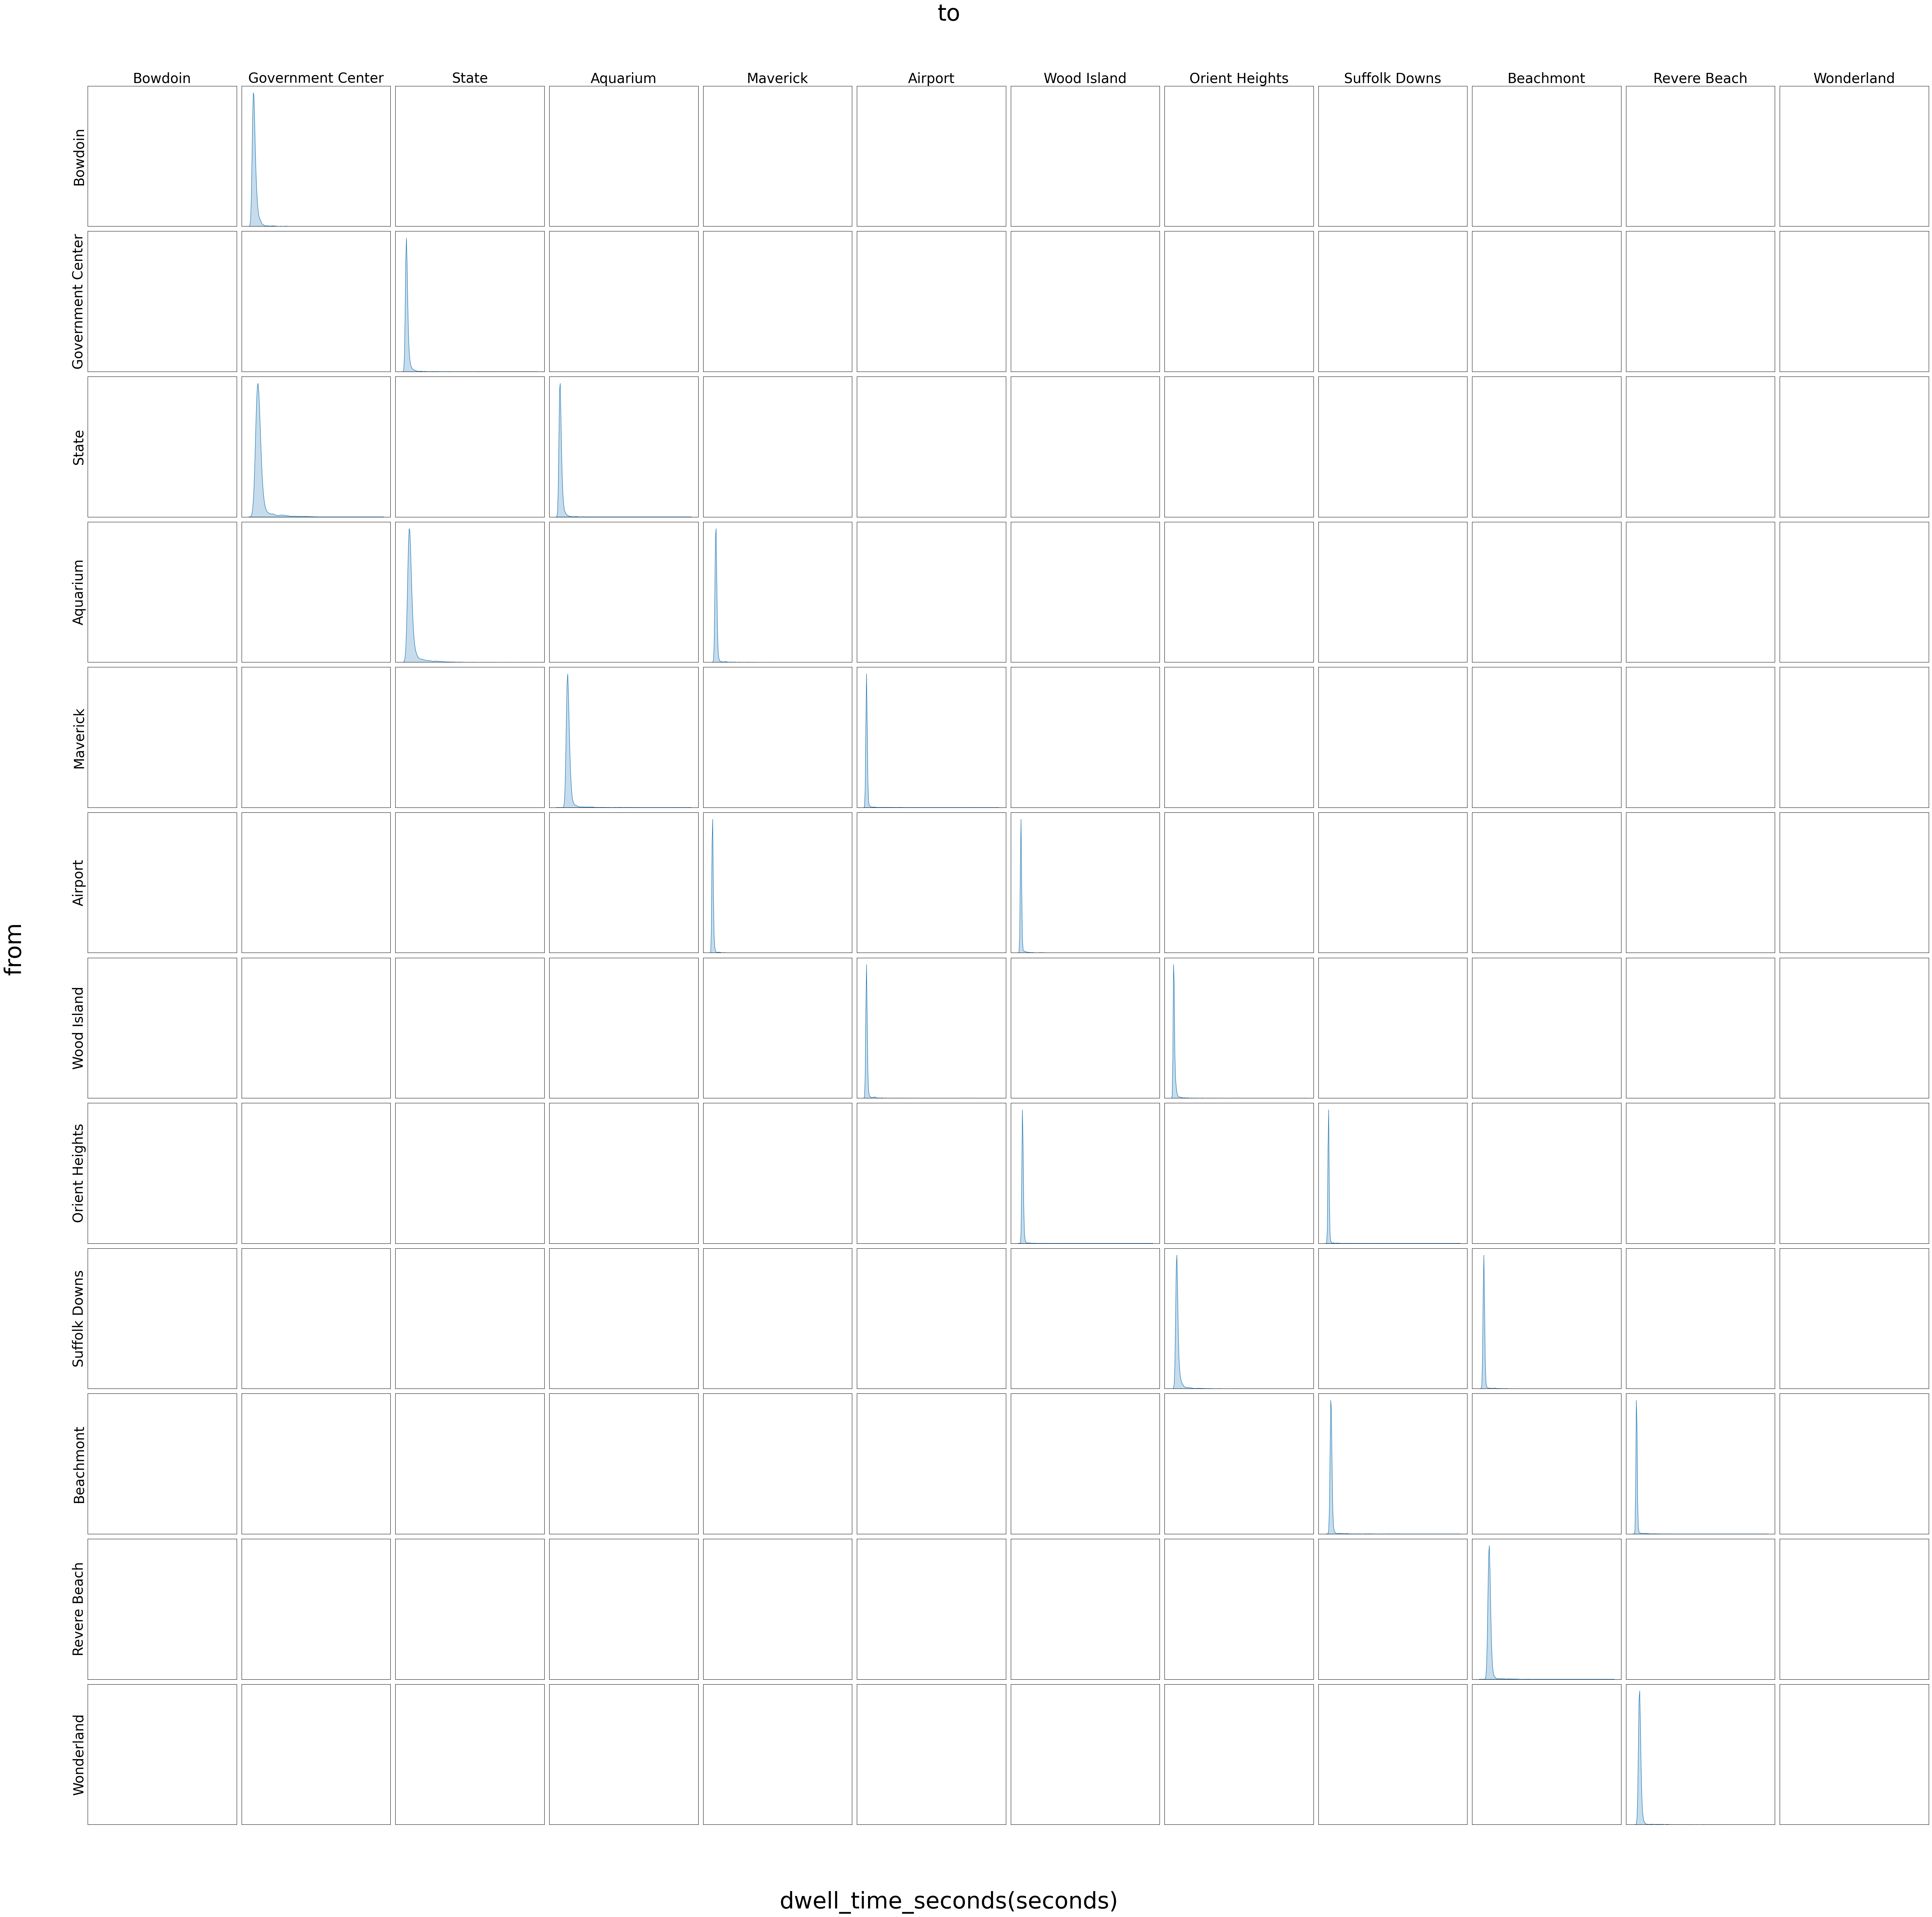

In [68]:
plot_kde(blue, 'dwell_time_seconds', blue_stops)

## find best fit distribution

In [8]:
from_station = blue_stops[0]
to_station = blue_stops[1]

temp = blue.loc[(blue['fromstation']==from_station) & (blue['stop_name']==to_station)]

In [66]:
get_aic(blue, 'travel_time_seconds')

weibull_min     96869.67
lognorm         79617.27
gamma           83420.24
expon          113032.88
dtype: float64


In [67]:
get_aic(blue, 'dwell_time_seconds')

weibull_min    103123.06
lognorm         89297.08
gamma           94888.12
expon          110192.19
dtype: float64


## get log likelihood parameters (sigma, scale)

In [75]:
def get_loglikelihood_params(df):
    ret_df = {
    'from_station':     [],
    'to_station':       [],
    'dwell_params':     [],
    'travel_params':    [],
    }

    key = ['s', 'loc', 'scale']

    for from_station in df['fromstation'].unique():
        temp = df[df['fromstation']==from_station]
        for to_station in temp['stop_name'].unique():
            dwell_time = df[(df['stop_name']==to_station)&(df['fromstation']==from_station)]['dwell_time_seconds']
            travel_time = df[(df['stop_name']==to_station)&(df['fromstation']==from_station)]['travel_time_seconds']

            ret_df['from_station'].append(from_station)
            ret_df['to_station'].append(to_station)
            ret_df['dwell_params'].append(dict(zip(key, scipy.stats.lognorm.fit(dwell_time, floc=0))))
            ret_df['travel_params'].append(dict(zip(key, scipy.stats.lognorm.fit(travel_time, floc=0))))

    return pd.DataFrame(ret_df)

In [90]:
params_df = get_loglikelihood_params(blue)

In [ ]:
params_df

array(['Orient Heights', 'Wood Island', 'Wonderland', 'Airport',
       'Revere Beach', 'Beachmont', 'Maverick', 'Suffolk Downs',
       'Aquarium', 'State', 'Bowdoin', 'Government Center'], dtype=object)

## complete tablen fill in missing edge

In [91]:
params_df = pd.concat([params_df,
          pd.DataFrame({
              'from_station':['Government Center', 'Revere Beach'],
              'to_station':['Bowdoin','Wonderland'],
              'dwell_params':[
                  params_df[(params_df['from_station']=='Bowdoin')&(params_df['to_station']=='Government Center')]['dwell_params'],
                  params_df[(params_df['from_station']=='Wonderland')&(params_df['to_station']=='Revere Beach')]['dwell_params']
              ],
              'travel_params':[
                  params_df[(params_df['from_station']=='Bowdoin')&(params_df['to_station']=='Government Center')]['travel_params'],
                  params_df[(params_df['from_station']=='Wonderland')&(params_df['to_station']=='Revere Beach')]['travel_params']
              ],

          })], ignore_index=True)

## generate graph network

In [99]:
params_df['edge'] = params_df.apply(lambda x: (x['from_station'],
                                               x['to_station'],
                                                 {'dwell': x['dwell_params'],'travel': x['travel_params']}), axis=1)


In [79]:
G = nx.DiGraph()

In [100]:
G.add_edges_from(params_df['edge'].to_list())

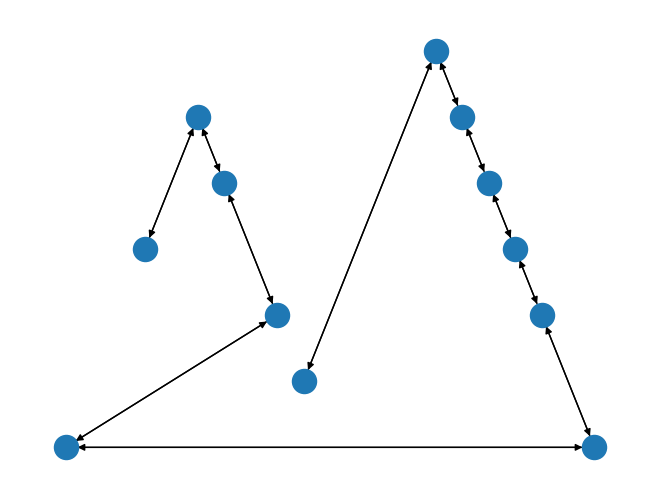

In [101]:
nx.draw_planar(G)

In [ ]:
blue